In [16]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [17]:
data = pd.read_csv('/content/employee_attrition_data.csv')
data

,Employee_ID,Age,Gender,Department,Job_Title,Years_at_Company,Satisfaction_Level,Average_Monthly_Hours,Promotion_Last_5Years,Salary,Attrition
0,0,27,Male,Marketing,Manager,9,0.586251,151,0,60132,0
1,1,53,Female,Sales,Engineer,10,0.261161,221,1,79947,0
2,2,59,Female,Marketing,Analyst,8,0.304382,184,0,46958,1
3,3,42,Female,Engineering,Manager,1,0.480779,242,0,40662,0
4,4,44,Female,Sales,Engineer,10,0.636244,229,1,74307,0
...,...,...,...,...,...,...,...,...,...,...,...
995,995,39,Female,HR,HR Specialist,3,0.377435,239,0,71403,0
996,996,50,Male,Engineering,Manager,1,0.431152,154,0,30181,1
997,997,52,Male,Engineering,Analyst,3,0.647102,206,0,64143,0
998,998,37,Female,HR,HR Specialist,2,0.304813,241,0,74383,1


In [18]:
# Mã hóa các cột phân loại
encoder = LabelEncoder()
data['Gender'] = encoder.fit_transform(data['Gender'])
data['Department'] = encoder.fit_transform(data['Department'])
data['Job_Title'] = encoder.fit_transform(data['Job_Title'])

In [19]:
# Xây dựng biến phụ thuộc và độc lập
X = data.drop(columns=['Attrition', 'Employee_ID'])  # Loại bỏ cột 'Attrition' và 'Employee_ID'
y = data['Attrition']  # 'Attrition' là biến mục tiêu

In [20]:
# Chia dữ liệu thành tập huấn luyện và tập kiểm tra (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [21]:
# Chuẩn hóa dữ liệu (Standardization)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
# Áp dụng PCA để giảm chiều dữ liệu (nếu cần thiết)
pca = PCA(n_components=5)  # Giảm xuống 5 chiều, có thể thay đổi theo dữ liệu
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [23]:
# Xây dựng mô hình KNN
knn = KNeighborsClassifier(n_neighbors=5)

In [24]:
# Huấn luyện mô hình
knn.fit(X_train_pca, y_train)

KNeighborsClassifier()

In [25]:
# Dự đoán trên tập kiểm tra
y_pred = knn.predict(X_test_pca)

In [26]:
# Đánh giá mô hình
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.5


In [27]:
# In classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.51      0.42      0.46       102
           1       0.49      0.58      0.53        98

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.50      0.50      0.50       200



In [28]:
# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", conf_matrix)


Confusion Matrix:
 [[43 59]
 [41 57]]


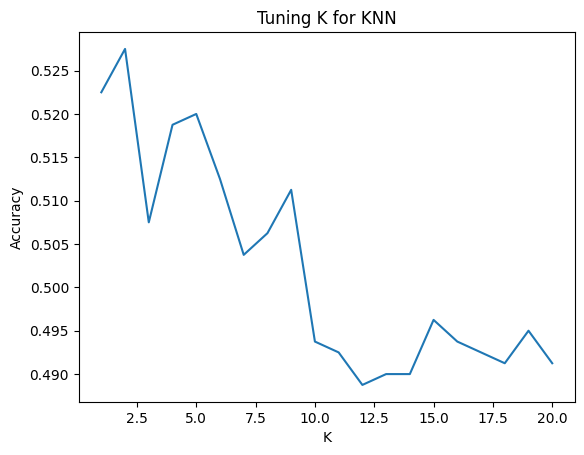

In [29]:
# Tuning K để tìm giá trị tối ưu
k_range = range(1, 21)
k_scores = []

# Tìm K tốt nhất với Cross-Validation
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_pca, y_train, cv=10, scoring='accuracy')
    k_scores.append(scores.mean())

# Vẽ biểu đồ độ chính xác theo K
plt.plot(k_range, k_scores)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Tuning K for KNN')
plt.show()


In [30]:
# Chọn K có độ chính xác cao nhất
best_k = k_range[k_scores.index(max(k_scores))]
print(f"Best K: {best_k}")

Best K: 2


In [31]:
# Huấn luyện lại mô hình với K tối ưu
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_pca, y_train)

# Dự đoán và đánh giá lại
y_pred_best = knn_best.predict(X_test_pca)
accuracy_best = accuracy_score(y_test, y_pred_best)
print(f"\nAccuracy with Best K ({best_k}): {accuracy_best}")


Accuracy with Best K (2): 0.5


In [32]:
# In classification report với K tốt nhất
print("\nClassification Report with Best K:\n", classification_report(y_test, y_pred_best))

# Confusion Matrix với K tốt nhất
conf_matrix_best = confusion_matrix(y_test, y_pred_best)
print("\nConfusion Matrix with Best K:\n", conf_matrix_best)

# So sánh độ chính xác của mô hình ban đầu và mô hình với K tốt nhất
print(f"\nImprovement in accuracy: {accuracy_best - accuracy}")


Classification Report with Best K:
               precision    recall  f1-score   support

           0       0.51      0.65      0.57       102
           1       0.49      0.35      0.40        98

    accuracy                           0.50       200
   macro avg       0.50      0.50      0.49       200
weighted avg       0.50      0.50      0.49       200


Confusion Matrix with Best K:
 [[66 36]
 [64 34]]

Improvement in accuracy: 0.0


In [38]:
attrition_by_department = {}
unique_departments = data['Department'].unique()
for department in unique_departments:
    # Lọc dữ liệu cho từng phòng ban
    department_data = data[data['Department'] == department]
    X_department = department_data.drop(columns=['Attrition', 'Employee_ID'])
    y_department = department_data['Attrition']

    # Chuẩn hóa dữ liệu
    X_department_scaled = scaler.transform(X_department)

    # Áp dụng PCA cho dữ liệu phòng ban (giống như đã làm với dữ liệu huấn luyện)
    X_department_pca = pca.transform(X_department_scaled)

    # Dự đoán
    y_pred_department = knn_best.predict(X_department_pca)

    # Tính số lượng và tỷ lệ nghỉ việc
    attrition_count = sum(y_pred_department)
    total_employees = len(X_department)
    attrition_percentage = (attrition_count / total_employees) * 100

    # Lưu kết quả
    attrition_by_department[department] = {
        'Total Employees': total_employees,
        'Attrition Count': attrition_count,
        'Attrition Percentage': attrition_percentage
    }

# In kết quả
print(attrition_by_department)

{3: {'Total Employees': 190, 'Attrition Count': 41, 'Attrition Percentage': 21.578947368421055}, 4: {'Total Employees': 209, 'Attrition Count': 55, 'Attrition Percentage': 26.31578947368421}, 0: {'Total Employees': 204, 'Attrition Count': 67, 'Attrition Percentage': 32.84313725490196}, 1: {'Total Employees': 206, 'Attrition Count': 64, 'Attrition Percentage': 31.06796116504854}, 2: {'Total Employees': 191, 'Attrition Count': 46, 'Attrition Percentage': 24.083769633507853}}


In [39]:
# Chuyển kết quả sang DataFrame để dễ dàng hiển thị
attrition_df = pd.DataFrame(attrition_by_department).T

attrition_df = attrition_df.sort_values(by='Attrition Percentage', ascending=False)

# Hiển thị kết quả
print(attrition_df)

   Total Employees  Attrition Count  Attrition Percentage
0            204.0             67.0             32.843137
1            206.0             64.0             31.067961
4            209.0             55.0             26.315789
2            191.0             46.0             24.083770
3            190.0             41.0             21.578947


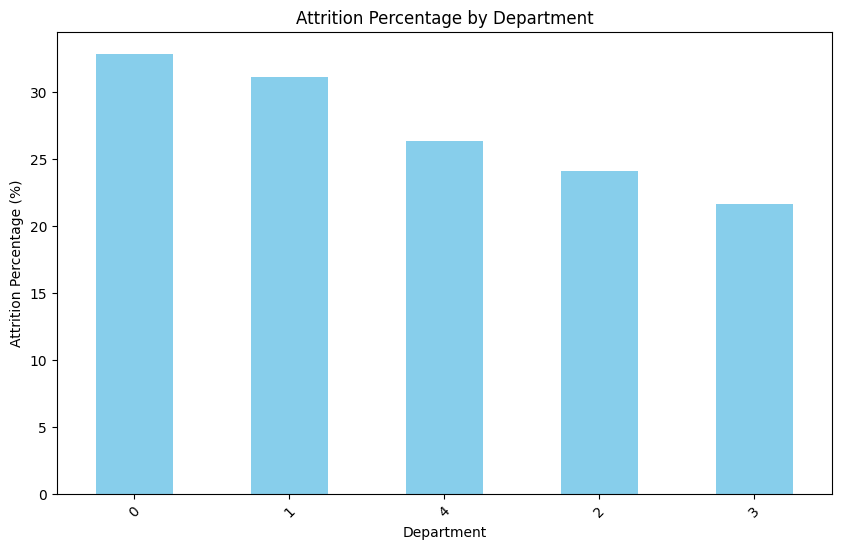

In [40]:
# Trực quan hóa kết quả
plt.figure(figsize=(10, 6))
attrition_df['Attrition Percentage'].plot(kind='bar', color='skyblue')
plt.xlabel('Department')
plt.ylabel('Attrition Percentage (%)')
plt.title('Attrition Percentage by Department')
plt.xticks(rotation=45)
plt.show()